In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
# Load dataset
df = pd.read_csv("heart.csv")

# Display dataset
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


In [5]:
#Data Pre-Procesing
# print(df.isnull().sum())
print(df.dtypes)
categorical_columns = ['sex', 'cp', 'restecg']

for col in categorical_columns:
    df[col] = df[col].astype('category')


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object



Outliers detected in chol:

     chol
28    417
85    564
96    394
220   407
246   409


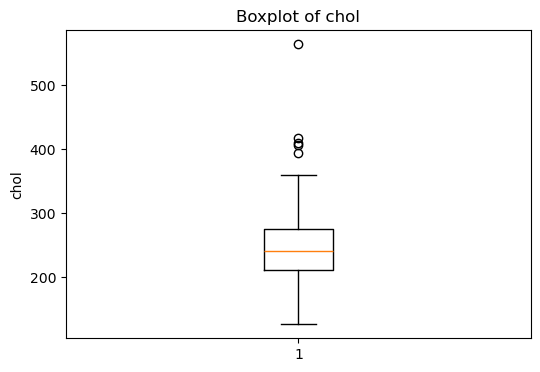


Outliers detected in thalach:

     thalach
272       71


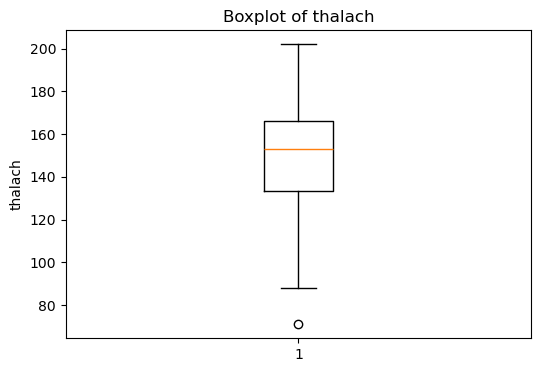

In [6]:
features = ['chol', 'thalach']

for feature in features:

    # Calculate Q1 and Q3
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Lower and Upper Bound
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect Outliers
    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]

    print(f"\nOutliers detected in {feature}:\n")
    print(outliers[[feature]])

    # Boxplot
    plt.figure(figsize=(6,4))

    plt.boxplot(df[feature])

    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)

    plt.show()

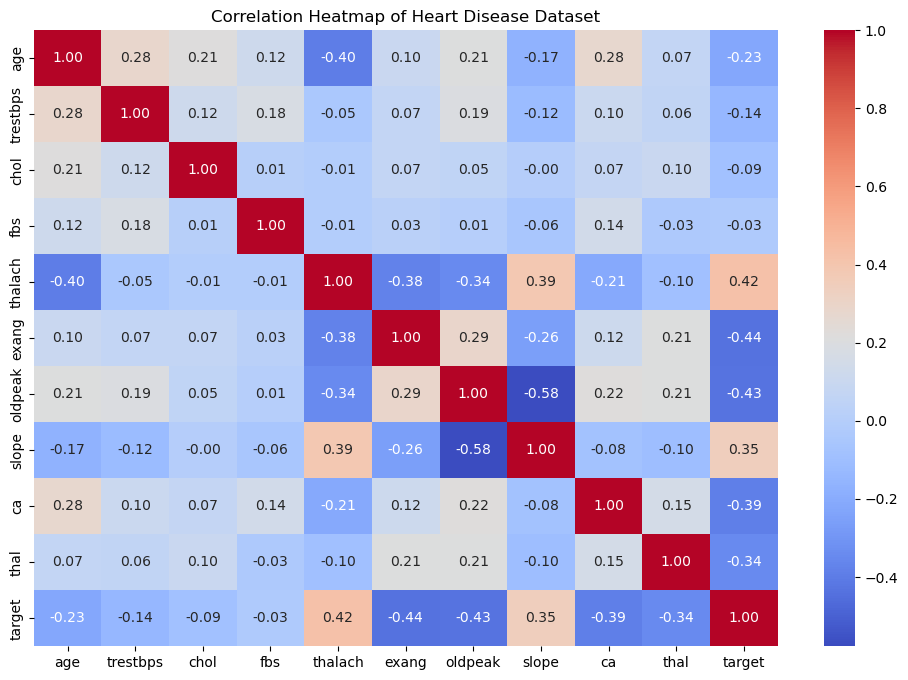

In [7]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Heart Disease Dataset")

plt.show()

In [8]:
#Feature Target inteerection matrix
target_corr = correlation_matrix['target'].sort_values(
    ascending=False
)

print("\nFeature-Target Interaction Matrix:\n")
print(target_corr)


Feature-Target Interaction Matrix:

target      1.000000
thalach     0.421741
slope       0.345877
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64


In [9]:
#Feature Engineering
# Create Age Adjusted Maximum Heart Rate

df['Age_Adjusted_MaxHR'] = 220 - df['age']

print("\nDataset after Feature Engineering:\n")
print(df.head())
numerical_columns = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)

print("\nScaled Dataset:\n")
print(df.head())



Dataset after Feature Engineering:

   age sex cp  trestbps  chol  fbs restecg  thalach  exang  oldpeak  slope  \
0   63   1  3       145   233    1       0      150      0      2.3      0   
1   37   1  2       130   250    0       1      187      0      3.5      0   
2   41   0  1       130   204    0       0      172      0      1.4      2   
3   56   1  1       120   236    0       1      178      0      0.8      2   
4   57   0  0       120   354    0       1      163      1      0.6      2   

   ca  thal  target  Age_Adjusted_MaxHR  
0   0     1       1                 157  
1   0     2       1                 183  
2   0     2       1                 179  
3   0     2       1                 164  
4   0     2       1                 163  

Scaled Dataset:

        age sex cp  trestbps      chol  fbs restecg   thalach  exang  \
0  0.952197   1  3  0.763956 -0.256334    1       0  0.015443      0   
1 -1.915313   1  2 -0.092738  0.072199    0       1  1.633471      0   
2 -1.474

In [10]:
df.to_csv("cleaned_heart_dataset.csv", index=False)

print("\nCleaned Dataset Saved")


Cleaned and Preprocessed Dataset Saved Successfully.


In [11]:
print("RULE-BASED HEART DISEASE RISK DETECTION")
df['Rule_Based_Risk'] = df['chol'].apply(
    lambda x: "High Risk" if x > 240 else "Low Risk"
)

print(df[['chol', 'Rule_Based_Risk']].head())

RULE-BASED HEART DISEASE RISK DETECTION
       chol Rule_Based_Risk
0 -0.256334        Low Risk
1  0.072199        Low Risk
2 -0.816773        Low Risk
3 -0.198357        Low Risk
4  2.082050        Low Risk


In [15]:
print("Rule based systems depend on fixed conditions Example: cholesterol > 240 means high risk.")
print("\nPredictive Data Science approaches analyze, multiple clinical features together such as:")
print("- age")
print("- cholesterol")
print("- chest pain")
print("- ECG results")
print("- heart rate")
print("\nPredictive approaches are more flexible and capable of identifying hidden patterns.")

Rule based systems depend on fixed conditions Example: cholesterol > 240 means high risk.

Predictive Data Science approaches analyze, multiple clinical features together such as:
- age
- cholesterol
- chest pain
- ECG results
- heart rate

Predictive approaches are more flexible and capable of identifying hidden patterns.
